# Customer Segmentation Analysis Using RFM and K-Means Clustering

## Project Overview

Customer segmentation is used to divide a customer base into groups with similar purchasing behaviour. Understanding these groups can help businesses tailor marketing activity, strengthen customer retention, and focus resources on customers with different levels of engagement and value.

In this project, transaction-level data from an online retail company is transformed into customer-level behavioural features. The **RFM framework** is used to measure Recency, Frequency, and Monetary Value, followed by K-Means clustering to identify distinct customer segments.

The analysis covers data quality assessment, cleaning, feature engineering, RFM analysis, distribution analysis, log transformation, feature standardisation, cluster selection using the Elbow Method, K-Means clustering, cluster profiling, and marketing recommendations.

## Objectives

The analysis aims to:

- Inspect and prepare the transaction-level dataset.
- Identify data quality issues that could affect customer-level analysis.
- Calculate customer-level Recency, Frequency, and Monetary Value.
- Calculate average purchase value and historical customer value.
- Prepare and standardise behavioural features for clustering.
- Determine a suitable number of clusters using the Elbow Method.
- Apply K-Means clustering to identify customer segments.
- Visualise and profile the resulting clusters.
- Translate the customer segments into targeted marketing actions.

## Tools and Technologies

- **Python**
- **pandas**
- **NumPy**
- **Matplotlib**
- **Seaborn**
- **scikit-learn**
- **Jupyter Notebook**

## Dataset

The analysis uses the **Online Retail** transaction dataset. The dataset contains invoice information, products, quantities, transaction dates, unit prices, customer IDs, and country information for an online retailer.

The transaction-level records are converted into customer-level behavioural measures before clustering is performed.
# 1. Importing Libraries

The first step is to import the Python libraries required for data manipulation, visualisation, and customer segmentation.


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 2. Data Loading & Initial Inspection

Before starting the analysis, I first load the dataset and take a look at its structure.

At this stage, I am mainly interested in understanding what each column represents, how large the dataset is, and whether there are any obvious data quality issues that need to be investigated before moving forward.

In [2]:
df = pd.read_excel(r"C:\Users\Admin\Downloads\Online Retail.xlsx\Online Retail.xlsx")

In [3]:
df.shape

(541909, 8)

In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# 3. Data Quality Assessment

Before cleaning the data, I wanted to understand what issues were actually present rather than removing records automatically.

I checked for missing values, duplicate records, cancelled transactions, invalid quantities, and invalid prices. These checks are important because the analysis is based on actual purchasing behaviour, so records that do not represent valid purchases could significantly affect the customer profiles.

Each issue is evaluated based on its potential impact on the RFM
analysis rather than being removed automatically.

In [9]:
print("=" * 40)
print("      Data Quality Assessment")
print("="* 40)
quality_report = pd.DataFrame({
    'Issue': [
        'Missing CustomerID',
        'Missing Description',
        'Duplicate Rows',
        'Cancelled Transactions',
        'Non-positive Quantity',
        'Non-positive UnitPrice'
    ],
    
    'Count': [
        df['CustomerID'].isna().sum(),
        df['Description'].isna().sum(),
        df.duplicated().sum(),
        df['InvoiceNo'].astype(str).str.startswith('C').sum(),
        (df['Quantity'] <= 0).sum(),
        (df['UnitPrice'] <= 0).sum()
    ]
})

quality_report['Percentage'] = (
    quality_report['Count'] / len(df) * 100
).round(2)

quality_report

      Data Quality Assessment


,Issue,Count,Percentage
0,Missing CustomerID,135080,24.93
1,Missing Description,1454,0.27
2,Duplicate Rows,5268,0.97
3,Cancelled Transactions,9288,1.71
4,Non-positive Quantity,10624,1.96
5,Non-positive UnitPrice,2517,0.46


In [10]:
print("="*30)
print("       Dataset Summary")
print("="*30)
dataset_summary= pd.DataFrame({
    "Metric" :["Total Transactions",
              "Total variables",
              "Unique Customers",
              "Countries",
              "Start Date",
              "End Date"],

    
    "Value" :[len(df) ,
             df.shape[1],
             df["CustomerID"].nunique(),
            df['Country'].nunique(),
            df['InvoiceDate'].min(),
            df['InvoiceDate'].max()
    ]
})

dataset_summary

       Dataset Summary


,Metric,Value
0,Total Transactions,541909
1,Total variables,8
2,Unique Customers,4372
3,Countries,38
4,Start Date,2010-12-01 08:26:00
5,End Date,2011-12-09 12:50:00


### Data Quality Findings

The initial assessment identified several issues that require attention
before customer-level analysis.

**Missing CustomerID:**  
135,080 transactions do not have a customer identifier. Because RFM
analysis requires transactions to be attributed to individual
customers, these records cannot be reliably used for customer
segmentation and will be removed.

**Missing Description:**  
1,454 transactions have a missing product description. Since product
description is not required to calculate Recency, Frequency, or Monetary
value, these records do not need to be removed for the purposes of this
analysis.

**Duplicate Records:**  
5,268 duplicate rows were identified. Keeping duplicate transactions
could artificially inflate customer purchase frequency and monetary
value, so they will be removed.

**Cancelled Transactions:**  
9,288 invoices are identified as cancellations through invoice numbers
beginning with `C`. These transactions do not represent completed
purchases and will therefore be excluded.

**Invalid Quantity:**  
10,624 transactions contain non-positive quantities. These records do
not represent valid positive purchases and will be excluded.

**Invalid Unit Price:**  
2,517 transactions contain non-positive unit prices. These transactions
cannot reliably represent positive sales value and will therefore be
excluded.

Overall, the cleaning process will focus on retaining valid,
completed transactions that can be attributed to identifiable
customers. This ensures that the Recency, Frequency, and Monetary metrics are calculated using meaningful customer purchase activity.

# 4. Data Cleaning

The quality assessment showed several issues that could affect the segmentation results.

Rather than trying to fix every column, I will focus on records that directly affect customer purchasing behaviour. The aim is to keep valid purchase transactions while removing records that could give a misleading picture of customer activity.

The cleaning steps will be:

* Remove transactions without a `CustomerID`
* Convert `CustomerID` to an integer after missing values are removed
* Remove duplicate records
* Remove cancelled invoices
* Remove transactions with non-positive quantities
* Remove transactions with non-positive prices

I will keep the `Description` column as it is because missing product descriptions do not affect the RFM calculations.


In [11]:
df_clean= df.copy()

In [12]:
df_clean= df_clean.dropna(subset=["CustomerID"])

In [13]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [14]:
df_clean= df_clean.drop_duplicates()

In [15]:
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')]


In [16]:
df_clean = df_clean[df_clean['Quantity'] > 0]

df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [17]:
print("Duplicates:", df_clean.duplicated().sum())
print("Missing CustomerID:", df_clean['CustomerID'].isna().sum())
print("Cancelled invoices:", df_clean['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Invalid Quantity:", (df_clean['Quantity'] <= 0).sum())
print("Invalid UnitPrice:", (df_clean['UnitPrice'] <= 0).sum())


Duplicates: 0
Missing CustomerID: 0
Cancelled invoices: 0
Invalid Quantity: 0
Invalid UnitPrice: 0


## 5. Transaction Value Calculation
The cleaned dataset is still at the transaction level, meaning one customer can appear across many rows.
Before calculating customer-level spending, I need a transaction-level measure of how much each purchase was worth.
I will create TotalPrice by multiplying the quantity purchased by the unit price.
This will later allow me to calculate the total amount spent by each customer.

In [18]:
df_clean["Total_Price"]= df_clean["Quantity"] * df_clean["UnitPrice"]

In [19]:
df_clean[["Quantity" , "UnitPrice" , "Total_Price"]].head()

,Quantity,UnitPrice,Total_Price
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 6. RFM Analysis

At this point, the transaction data has been cleaned, but clustering individual transactions would not make much sense.
**Recency**: measures how recently the customer made a purchase. Lower values mean the customer purchased more recently.
**Frequency**: measures how many unique invoices the customer has made. Higher values indicate more frequent purchasing.
**Monetary Value**: measures the total amount spent by the customer. Higher values indicate greater customer value.
Together, these three measures provide a simple way to describe differences in customer behaviour.

In [20]:
Reference_date= df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Reference Date:" , Reference_date)

Reference Date: 2011-12-10 12:50:00


In [21]:
Last_Purchase = df_clean.groupby("CustomerID")["InvoiceDate"].max()
Recency = (Reference_date - Last_Purchase ).dt.days
Frequency = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()
Monetary_Value = df_clean.groupby("CustomerID")["Total_Price"].sum()
RFM = pd.DataFrame({"Recency" : Recency , "Frequency": Frequency , "Monetary Value": Monetary_Value}).reset_index()

In [22]:
RFM.head()

,CustomerID,Recency,Frequency,Monetary Value
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [23]:
RFM.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.41,1721.81,12346.00,13813.25,15299.50,16778.75,18287.00
Recency,4338.0,92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,4338.0,4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary Value,4338.0,2048.69,8985.23,3.75,306.48,668.57,1660.60,280206.02


## 7. Descriptive Customer Metrics: Purchase Value, Frequency & CLV

The RFM table now provides a behavioural profile for each customer.

To add further descriptive context, I will calculate the average purchase value for each customer by dividing their total historical spending by their number of purchases.

This provides an additional measure of the typical value generated per purchase and helps distinguish customers who may have similar purchase frequency but different spending levels.

These measures are used for descriptive analysis and are not predictive Customer Lifetime Value estimates.


In [24]:
RFM["Average_Purchase_Value"]= (RFM["Monetary Value"] / RFM["Frequency"])


### Historical Customer Lifetime Value

Historical Customer Lifetime Value represents the total value generated by each customer during the observed transaction period. Since the dataset covers a limited historical period, this measure is treated as historical customer value rather than a predictive estimate of future lifetime value.

In [41]:
RFM["Customer_Lifetime_Value"] = RFM["Monetary Value"]

In [42]:
RFM[
    [
        "Recency",
        "Frequency",
        "Monetary Value",
        "Average_Purchase_Value",
        "Customer_Lifetime_Value"]
].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,4338.0,4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary Value,4338.0,2048.69,8985.23,3.75,306.48,668.57,1660.60,280206.02
Average_Purchase_Value,4338.0,417.65,1796.51,3.45,177.87,291.94,428.28,84236.25
Customer_Lifetime_Value,4338.0,2048.69,8985.23,3.75,306.48,668.57,1660.60,280206.02


## 8. RFM Distribution Analysis

Before applying a clustering algorithm, I want to understand how the RFM variables are distributed.

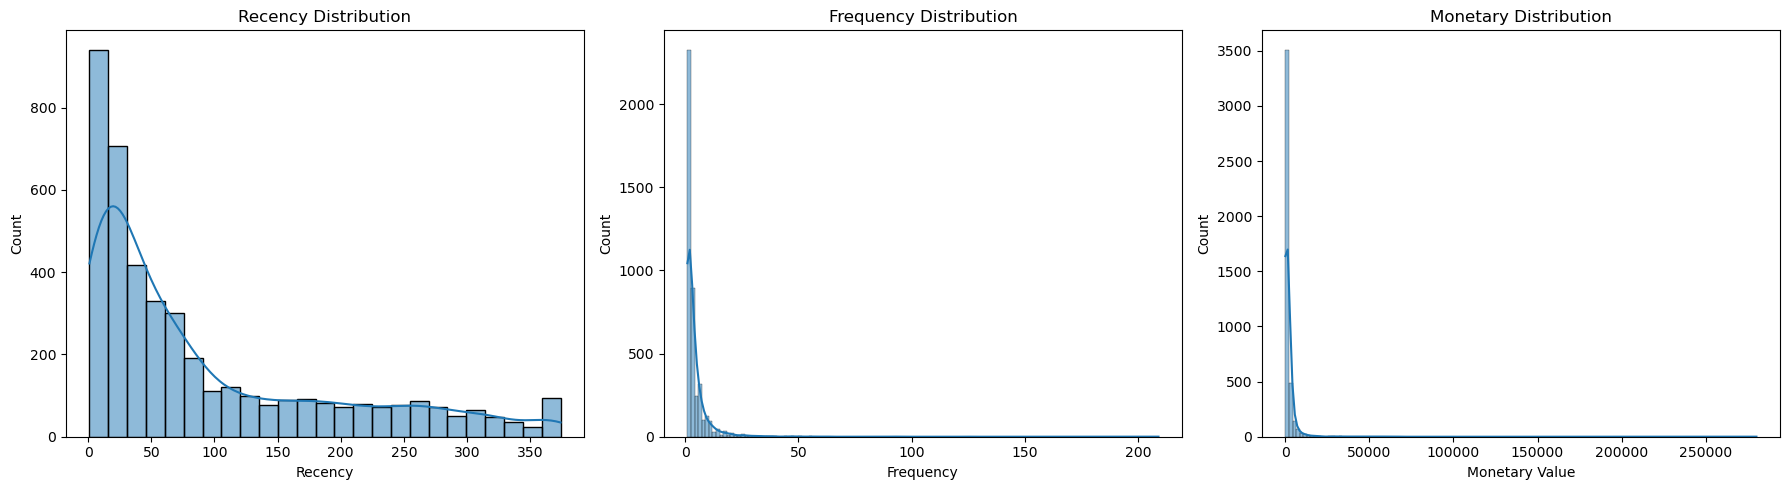

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    RFM['Recency'],
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Recency Distribution')

sns.histplot(
    RFM['Frequency'],
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Frequency Distribution')

sns.histplot(
    RFM['Monetary Value'],
    kde=True,
    ax=axes[2]
)
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

### 8.1 Distribution Analysis Findings

The RFM distributions show substantial right-skewness in Frequency and Monetary Value, with a relatively small number of customers accounting for unusually high purchase frequency and spending.

Since K-Means clustering is based on distances between observations, extreme values may have a disproportionate influence on the resulting customer segments.

A log transformation is therefore applied to Frequency and Monetary Value to reduce the effect of extreme values and produce a more balanced distribution before clustering.

In [27]:
# Reduce the effect of extreme values
RFM['Frequency_Log'] = np.log1p(RFM['Frequency'])
RFM['Monetary_Log'] = np.log1p(RFM['Monetary Value'])

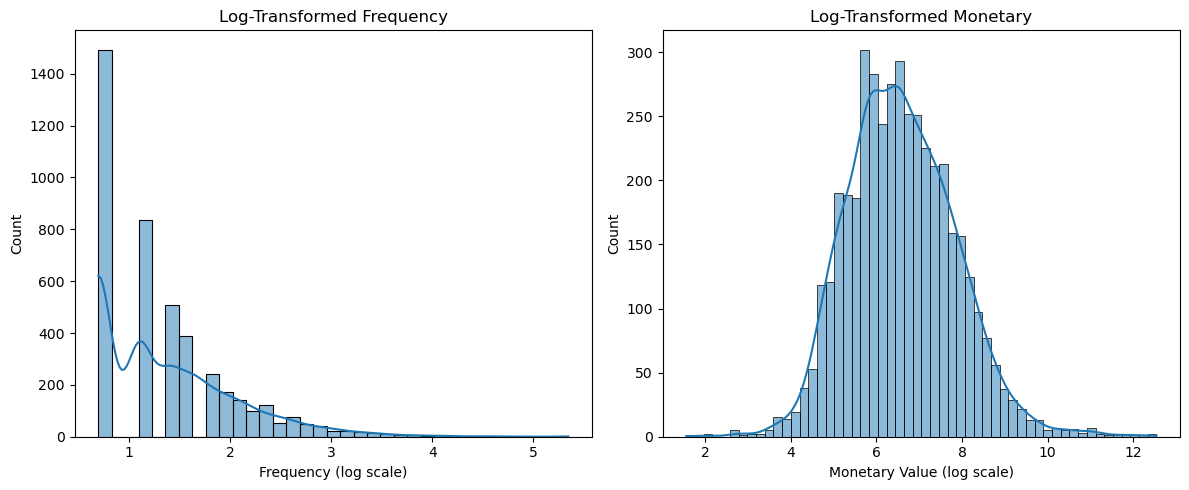

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(RFM['Frequency_Log'], kde=True, ax=axes[0])
axes[0].set_title('Log-Transformed Frequency')
axes[0].set_xlabel('Frequency (log scale)')

sns.histplot(RFM['Monetary_Log'], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Monetary')
axes[1].set_xlabel('Monetary Value (log scale)')

plt.tight_layout()
plt.show()

# 9. Feature Standardisation

After reducing the effect of extreme values through log transformation, the RFM features are standardised before clustering.

Recency, transformed Frequency, and transformed Monetary Value remain on different numerical scales. Since K-Means clustering is based on distance calculations, standardisation is applied so that each feature contributes more comparably to the clustering process.

The `StandardScaler` is fitted to the selected RFM features and the resulting standardised values are used as the input for K-Means.

In [29]:
rfm_features = RFM[
    ["Recency", "Frequency_Log", "Monetary_Log"]]

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [31]:
rfm_scaled[:5]

array([[ 2.33457414, -0.95521426,  3.7077163 ],
       [-0.90534032,  1.07442519,  1.41490344],
       [-0.17535959,  0.38630445,  0.72002428],
       [-0.73534481, -0.95521426,  0.70228691],
       [ 2.17457836, -0.95521426, -0.61451388]])

# 10. Choosing the Number of Clusters

K-Means requires me to decide how many customer groups, or clusters, I want to create.

Rather than choosing this number Randomly, I will test several possible values of K and use the Elbow Method to identify a reasonable point.
The Elbow Method uses inertia, which measures how close customers are to the centre of their assigned cluster.
As more clusters are added, inertia will naturally decrease. I am therefore looking for the point where adding another cluster starts producing a much smaller improvement.

In [32]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

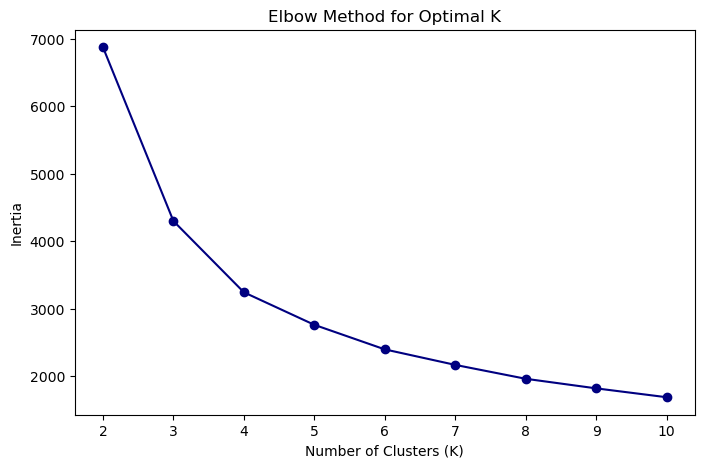

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o',
    color='navy'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

# Observation:

The Elbow Method shows a substantial decrease in inertia as the number of clusters increases from K = 2 to K = 4. After K = 4, the reduction in inertia becomes considerably smaller, indicating diminishing returns from adding additional clusters.
Therefore, **K = 4** was selected as a suitable number of clusters for this analysis, providing a reasonable balance between cluster compactness and model simplicity.


# 11. K-Means Clustering

The Elbow Method indicated that **K = 4** provides a suitable balance between reducing within-cluster variation and maintaining a manageable number of customer segments. Therefore, the K-Means algorithm is applied with **four clusters**.

The resulting clusters will then be analyzed based on the characteristics of their customers to identify and interpret the different customer segments.

In [34]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10)


RFM['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [35]:
RFM.head().round(2)

,CustomerID,Recency,Frequency,Monetary Value,Average_Purchase_Value,Frequency_Log,Monetary_Log,Cluster
0,12346,326,1,77183.60,77183.60,0.69,11.25,3
1,12347,2,7,4310.00,615.71,2.08,8.37,2
2,12348,75,4,1797.24,449.31,1.61,7.49,3
3,12349,19,1,1757.55,1757.55,0.69,7.47,3
4,12350,310,1,334.40,334.40,0.69,5.82,1


# 12. Visualising Customer Clusters

The clustering algorithm has now assigned every customer to a segment.
I will visualise the clusters using different combinations of RFM variables to see how clearly the groups differ from one another.

Because the clustering was performed using all three RFM features, these two-dimensional plots are mainly useful for understanding the structure of the resulting segments visually.


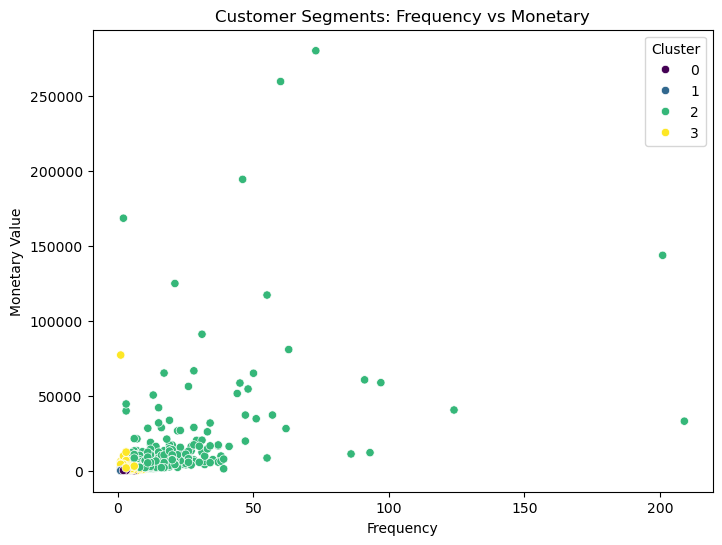

In [36]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=RFM,
    x='Frequency',
    y='Monetary Value',
    hue='Cluster',
    palette='viridis'
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.show()

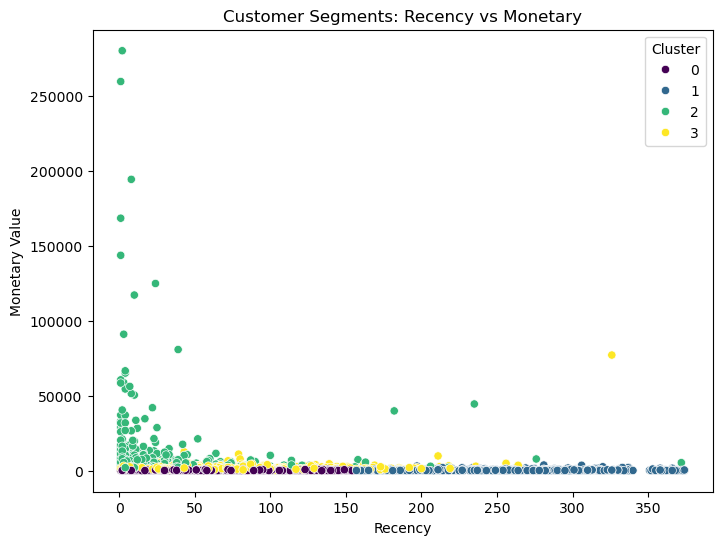

In [37]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=RFM,
    x='Recency',
    y='Monetary Value',
    hue='Cluster',
    palette='viridis'
)

plt.title('Customer Segments: Recency vs Monetary')
plt.show()

## 13. Cluster Profiling

After applying K-Means with four clusters, I calculated the average Recency, Frequency, and Monetary Value for each cluster to understand the behavioural characteristics of the resulting customer segments.

The number of customers in each cluster is also examined to understand how the customer base is distributed across the identified segments.




In [43]:
cluster_profile = RFM.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary Value', 'mean'),
    Avg_Purchase_Value=('Average_Purchase_Value', 'mean')
).round(2)
cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Purchase_Value
Cluster,,,,,
0,1377,58.04,1.51,384.22,285.63
1,938,259.41,1.37,385.39,295.09
2,571,19.77,15.84,9823.43,731.64
3,1452,46.06,4.21,1644.26,498.54


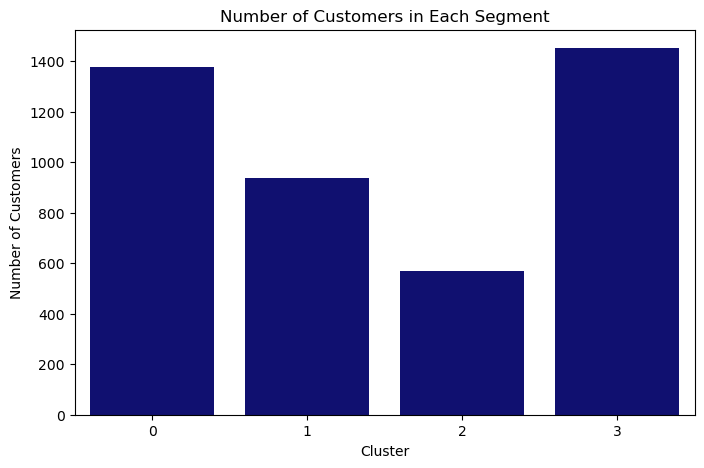

In [40]:
cluster_counts = RFM["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    color="Navy"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Segment")

plt.show()

## Customer Segment Interpretation

The four clusters represent distinct customer behaviours based on their Recency, Frequency, and Monetary Value.

### Cluster 2 – High-Value Loyal Customers

**571 customers | Avg. Recency: 19.77 days | Avg. Frequency: 15.84 | Avg. Monetary Value: 9,823.43**

This is the strongest customer segment in the analysis. Customers in this group have purchased relatively recently, make purchases much more frequently than the other segments, and generate substantially higher historical spending.

The combination of low Recency, high Frequency, and high Monetary Value indicates a highly engaged and valuable customer group.


---

### Cluster 3 – Active Mid-Value Customers

**1,452 customers | Avg. Recency: 46.06 days | Avg. Frequency: 4.21 | Avg. Monetary Value: 1,644.26**

This is the largest segment. Customers are relatively recent and show moderate purchasing frequency and historical spending compared with the high-value group.

They are active customers with established purchasing behaviour, but their value remains considerably below Cluster 2.

---

### Cluster 0 – Recent Low-Value Customers

**1,377 customers | Avg. Recency: 58.04 days | Avg. Frequency: 1.51 | Avg. Monetary Value: 384.22**

These customers have relatively recent activity but low purchase frequency and low historical spending. Their recent purchase behaviour suggests that they are not inactive, but they have not yet developed strong repeat-purchasing behaviour.

---

### Cluster 1 – At-Risk / Inactive Customers

**938 customers | Avg. Recency: 259.41 days | Avg. Frequency: 1.37 | Avg. Monetary Value: 385.39**

This segment has by far the highest Recency, meaning customers have gone considerably longer since their last purchase. They also have the lowest purchasing frequency and low historical spending.

The combination of long inactivity and limited purchasing behaviour indicates a group with weak recent engagement.



# 14. Marketing Recommendations

The customer segments show clear differences in engagement and historical value. These differences can be used to develop more targeted marketing strategies rather than applying the same approach to all customers.

### Cluster 2 – High-Value Loyal Customers

**Objective: Retain and strengthen loyalty**

* Prioritise customer retention and loyalty initiatives.
* Provide personalised offers or early access to selected products.
* Use loyalty rewards to encourage continued engagement.
* Focus on value-added experiences rather than relying heavily on discounts.

### Cluster 3 – Active Mid-Value Customers

**Objective: Increase customer value**

* Use cross-selling and upselling strategies to increase spending.
* Recommend complementary products based on previous purchases.
* Introduce loyalty incentives that encourage more frequent purchases.
* Identify opportunities to gradually move customers toward the high-value segment.

### Cluster 0 – Recent Low-Value Customers

**Objective: Encourage repeat purchases**

* Encourage a second or additional purchase through personalised recommendations.
* Use targeted introductory offers where appropriate.
* Recommend relevant products based on recent purchasing behaviour.
* Monitor whether customers develop stronger repeat-purchase behaviour over time.

### Cluster 1 – At-Risk / Inactive Customers

**Objective: Reactivate customers**

* Launch targeted win-back campaigns.
* Use time-limited incentives to encourage reactivation.
* Remind customers of relevant products, new arrivals, or offers.
* Prioritise customers with relatively stronger historical value when allocating campaign resources.

These recommendations are potential strategies based on the observed customer profiles. Their actual effectiveness would need to be evaluated using campaign-response and customer engagement data.


# 15. Key Insights & Conclusion

This analysis transformed transaction-level retail data into customer-level behavioural profiles using the **RFM framework: Recency, Frequency, and Monetary Value**.

The initial data quality assessment identified missing customer identifiers, duplicate records, cancelled transactions, and non-positive quantities and prices. Records that could not be reliably used to represent valid customer purchases were excluded before calculating the RFM measures.
The analysis showed substantial right-skewness in Frequency and Monetary Value, with a relatively small number of customers showing much higher purchasing activity and spending. Log transformation was therefore applied to Frequency and Monetary Value before standardisation.

The standardised RFM features were then used as inputs for K-Means clustering. The Elbow Method was used to compare different values of K, with **K = 4 selected as a suitable clustering solution** for this analysis.

The resulting four segments reveal clear differences in customer engagement and historical value. **Cluster 2** represents the highest-value and most engaged customers, while **Cluster 3** consists of active customers with moderate value. **Cluster 0** contains relatively recent customers with low purchasing frequency and spending, while **Cluster 1** represents customers with the longest periods since their last purchase and relatively low purchasing activity.

These differences provide a basis for more targeted customer strategies. High-value customers can be prioritised for retention, active mid-value customers can be developed through cross-selling and upselling, recent low-value customers can be encouraged to make repeat purchases, and inactive customers can be targeted through win-back campaigns.

Overall, the analysis demonstrates how transaction data can be transformed into actionable customer segments using RFM analysis and K-Means clustering. Future analysis could incorporate campaign-response data, customer tenure, revenue contribution by segment, or predictive Customer Lifetime Value modelling to further support customer strategy.
